# External validation — does the model work on attacks it has never seen?

Every number in the *_analysis.ipynb notebooks comes from the provided 23 attacks
from one device. Cross-validation cannot tell us whether the model learned
*screen recapture* or learned *that device*, because both hypotheses predict the same
in-domain result. Leave-one-device-out was impossible with one device.

This notebook answers the question with data the model has never seen, from two public huggingface
replay-attack datasets captured by other people on other equipment.

## Results

| | attacks | APCER @ 1% BPCER |
|---|---|---|
| In-domain (cross-validated) | 23, one device | **0.17** |
| AxonData `Display_replay_attacks` | 40 frames / 5 videos | **1.00** |
| UniqueData `monitors-replay-attacks` | 60 frames / 10 videos | **0.95** |
| **External combined** | **100 frames / 15 videos** | **0.97** |

**The model detects essentially none of the unseen attacks.** 97 of 100 external attack
frames are accepted as genuine at the deployable operating point. The in-domain figure of
0.17 does not survive contact with a different capture pipeline.

This is the most important result in the project, and it is a negative one. Sections below
establish it is real and diagnose *why* — the mechanism turns out to be specific and
instructive rather than a generic "it didn't generalise".

## Data sources

Both are creative-commons licensed and publicly downloadable, and contain real screen-replay attacks captured
independently of our training data:

| dataset | licence | content used |
|---|---|---|
| [`AxonData/Display_replay_attacks`](https://huggingface.co/datasets/AxonData/Display_replay_attacks) | CC-BY-4.0 | 5 genuine stills, 5 attack videos |
| [`UniqueData/monitors-replay-attacks-dataset`](https://huggingface.co/datasets/UniqueData/monitors-replay-attacks-dataset) | CC-BY-NC-ND-4.0 | 10 attack videos |

Attacks are supplied as video, so frames are extracted — appropriate, since our model is
single-image and scores frames independently.

**Counting caveat, and it matters.** 100 frames come from **15 videos**. Frames within a
video are near-duplicates, so the effective independent sample size is 15, not 100.
Confidence intervals below are computed at the *video* level for that reason - the same
mistake as treating 23 images from one device as 23 independent attacks would be.

In [1]:
import json
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import load
from scipy.stats import beta

from infer import extract, FEATURE_ORDER

EXTERNAL = Path("external")
cfg = json.loads(Path("artefacts/config.json").read_text())
model = load("artefacts/model.joblib")
THRESHOLDS = cfg["thresholds_by_bpcer"]

print(f"model: {len(cfg['feature_order'])} features, calibrated over "
      f"{cfg.get('calibration_seeds')} seeds")
print(f"thresholds: {', '.join(f'{k}={v:.4f}' for k, v in THRESHOLDS.items())}")

model: 9 features, calibrated over 20 seeds
thresholds: 0.001=0.9999, 0.01=0.8831, 0.05=0.2859, 0.1=0.0874


In [2]:
def extract_frames(video_dir, out_dir, n_frames, pattern="*"):
    """Evenly spaced frames, skipping the first and last 10%.

    Start and end frames are often motion-blurred or mid-transition; the middle
    80% is more representative of what a live capture would see.
    """
    out_dir.mkdir(parents=True, exist_ok=True)
    if list(out_dir.glob("*.png")):
        return sorted(out_dir.glob("*.png"))  # already extracted
    for video in sorted(Path(video_dir).glob(pattern)):
        if video.suffix.lower() not in {".mp4", ".mov"}:
            continue
        cap = cv2.VideoCapture(str(video))
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        for i in range(n_frames):
            cap.set(cv2.CAP_PROP_POS_FRAMES,
                    int(total * (0.1 + 0.8 * i / max(n_frames - 1, 1))))
            ok, frame = cap.read()
            if ok:
                cv2.imwrite(str(out_dir / f"{video.stem}_f{i}.png"), frame)
        cap.release()
    return sorted(out_dir.glob("*.png"))


axon_attack = extract_frames(EXTERNAL / "axon_display/attack",
                             EXTERNAL / "axon_display/attack_frames", n_frames=8)
monitors_attack = extract_frames(EXTERNAL / "monitors",
                                 EXTERNAL / "monitors_frames", n_frames=6)
axon_real = sorted((EXTERNAL / "axon_display/real").glob("*.jpg"))
print(f"{len(axon_attack)} + {len(monitors_attack)} attack frames, {len(axon_real)} genuine stills")

40 + 60 attack frames, 5 genuine stills


In [3]:
def score_files(paths, label, source):
    rows = []
    for p in paths:
        # video frames share a stem prefix; group by it so statistics can be
        # computed per video rather than per frame
        video = p.stem.rsplit("_f", 1)[0] if label == "attack" else p.stem
        rows.append({"label": label, "source": source, "video": video,
                     "file": p.name, **extract(p, cfg["image_size"])})
    return rows


ext = pd.DataFrame(
    score_files(axon_attack, "attack", "axon")
    + score_files(monitors_attack, "attack", "monitors")
    + score_files(axon_real, "real", "axon")
)
ext["score"] = model.predict_proba(ext[FEATURE_ORDER].to_numpy())[:, 1]
ext.to_csv(EXTERNAL / "external_scores.csv", index=False)

print(ext.groupby(["source", "label"])["score"]
      .agg(["count", "median", "min", "max"]).round(4).to_string())

                 count  median  min     max
source   label                             
axon     attack     40  0.0018  0.0  0.0472
         real        5  0.0004  0.0  0.7634
monitors attack     60  0.0016  0.0  0.9986


## The result

An attack is *accepted* (missed) when its score falls below the operating threshold. External attacks score around 0.001–0.005, where our training attacks score above 0.98. The model is confidently wrong.

In [4]:
def clopper_pearson(k, n, alpha=0.05):
    lo = beta.ppf(alpha / 2, k, n - k + 1) if k > 0 else 0.0
    hi = beta.ppf(1 - alpha / 2, k + 1, n - k) if k < n else 1.0
    return lo, hi


attacks = ext[ext.label == "attack"]
rows = []
for key in ("0.001", "0.01", "0.05", "0.1"):
    thr = THRESHOLDS[key]
    by_frame = (attacks.score <= thr)
    # A video counts as missed if the majority of its frames are accepted --
    # the honest unit, since frames within a video are near-duplicates.
    by_video = attacks.groupby("video").score.median() <= thr
    lo, hi = clopper_pearson(int(by_video.sum()), len(by_video))
    rows.append({
        "BPCER target": key,
        "APCER (frames)": by_frame.mean(),
        "frames missed": f"{int(by_frame.sum())}/{len(by_frame)}",
        "APCER (videos)": by_video.mean(),
        "videos missed": f"{int(by_video.sum())}/{len(by_video)}",
        "95% CI (videos)": f"[{lo:.2f}, {hi:.2f}]",
    })
print(pd.DataFrame(rows).set_index("BPCER target").round(3).to_string())

print("\nper attack video, median score (threshold @1% BPCER = "
      f"{THRESHOLDS['0.01']:.4f}):")
per_video = attacks.groupby(["source", "video"]).score.median().sort_values()
print(per_video.round(4).to_string())

              APCER (frames) frames missed  APCER (videos) videos missed 95% CI (videos)
BPCER target                                                                            
0.001                   1.00       100/100           1.000         15/15    [0.78, 1.00]
0.01                    0.97        97/100           1.000         15/15    [0.78, 1.00]
0.05                    0.90        90/100           0.933         14/15    [0.68, 1.00]
0.1                     0.87        87/100           0.867         13/15    [0.60, 0.98]

per attack video, median score (threshold @1% BPCER = 0.8831):
source    video              
axon      IMG_5987               0.0000
monitors  6                      0.0001
          1                      0.0001
          3                      0.0003
axon      IMG_5915               0.0004
monitors  9                      0.0009
          2                      0.0014
          5                      0.0017
axon      20240823_194131        0.0019
          VI

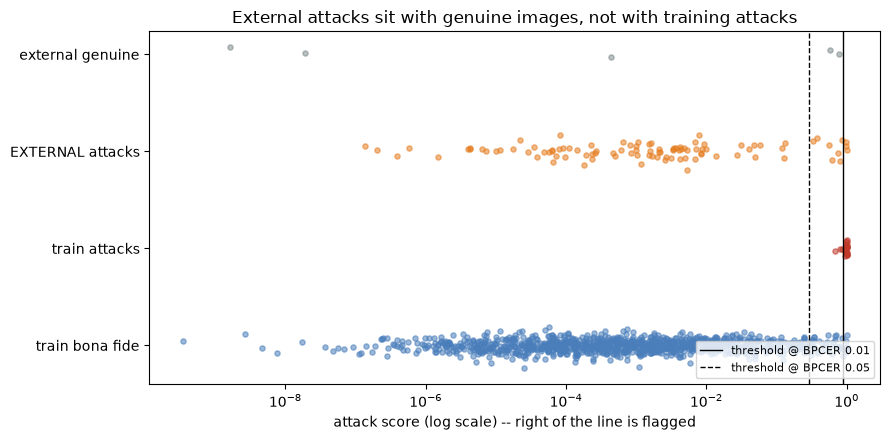

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
g = pd.read_csv("features_cache.csv")
p = pd.read_csv("features_patch_cache.csv").drop(columns=["label"])
train = g.merge(p, on="path")
train["score"] = model.predict_proba(train[FEATURE_ORDER].to_numpy())[:, 1]

groups = [
    ("train bona fide", train.loc[train.label == "bonafide", "score"], "#4a7ebb"),
    ("train attacks", train.loc[train.label == "screen", "score"], "#c0392b"),
    ("EXTERNAL attacks", attacks.score, "#e67e22"),
    ("external genuine", ext.loc[ext.label == "real", "score"], "#7f8c8d"),
]
rng = np.random.default_rng(0)
for i, (name, s, c) in enumerate(groups):
    ax.scatter(s, rng.normal(i, 0.06, len(s)), s=14, alpha=0.55, color=c)
for key, style in [("0.01", "-"), ("0.05", "--")]:
    ax.axvline(THRESHOLDS[key], ls=style, color="k", lw=1,
               label=f"threshold @ BPCER {key}")
ax.set_xscale("log")
ax.set_yticks(range(len(groups)), [g[0] for g in groups])
ax.set_xlabel("attack score (log scale) -- right of the line is flagged")
ax.set_title("External attacks sit with genuine images, not with training attacks")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()

## Why it failed

The interesting part. If the model had degraded gracefully we would suspect noise; instead
it is confidently wrong, which points at a systematic cause. Comparing median feature
values across the four groups shows exactly where the model's assumptions break.

In [6]:
comparison = pd.DataFrame({
    "train_bona": train.loc[train.label == "bonafide", FEATURE_ORDER].median(),
    "train_attack": train.loc[train.label == "screen", FEATURE_ORDER].median(),
    "ext_attack": attacks[FEATURE_ORDER].median(),
})
coefs = pd.Series(model[-1].coef_[0], index=FEATURE_ORDER)
comparison["coefficient"] = coefs
# Does the external attack look more like our bona fide or our attacks?
comparison["resembles"] = np.where(
    (comparison.ext_attack - comparison.train_bona).abs()
    < (comparison.ext_attack - comparison.train_attack).abs(),
    "BONA FIDE", "attack")

print(comparison.reindex(coefs.abs().sort_values(ascending=False).index).round(4).to_string())

wrong = comparison.index[comparison.resembles == "BONA FIDE"]
share = coefs[wrong].abs().sum() / coefs.abs().sum()
print(f"\n{len(wrong)} of {len(FEATURE_ORDER)} features point the WRONG WAY on external "
      f"attacks,\ncarrying {share:.0%} of the model's total |coefficient| weight:")
print(" ", list(wrong))

                     train_bona  train_attack  ext_attack  coefficient  resembles
noise                    0.8964        1.7525      0.4590       4.1944  BONA FIDE
hf_energy                0.7160        0.7585      0.6020      -1.8854  BONA FIDE
perpendicular_ratio      0.0774        0.0938      0.1344       1.5899     attack
prewitt_energy         865.7672     1459.4975    525.0128       1.2807  BONA FIDE
chroma_std              16.8624       21.4159     17.0201       1.0590  BONA FIDE
glare_area               0.0018        0.0001      0.0008      -0.9681     attack
hf_energy_pstd           0.0987        0.0688      0.0965      -0.9618  BONA FIDE
line_ratio               0.1041        0.2232      0.1241       0.4875  BONA FIDE
orientation_entropy      0.9928        0.9810      0.9475      -0.2740     attack

6 of 9 features point the WRONG WAY on external attacks,
carrying 78% of the model's total |coefficient| weight:
  ['noise', 'chroma_std', 'line_ratio', 'hf_energy', 'prewitt_ener

### The mechanism

**`noise` — the dominant feature (coefficient 4.19, the largest by 2.2×) — is inverted.**

| | median `noise` |
|---|---|
| training bona fide | 0.896 |
| training attacks | 1.753 |
| **external attacks** | **0.459** |

The model learned "noisier than a genuine capture ⇒ attack". External attacks are *quieter
than genuine images*, so that rule actively votes **bona fide** on them. The same holds for
`prewitt_energy`, `hf_energy` and `hf_energy_pstd` — all fine-detail measures, all inverted.

Two mechanisms plausibly produce this and **this data cannot fully separate them**:

1. **Video compression.** Our training attacks were PNG stills; these are H.264 frames.
   Inter-frame compression smooths high-frequency detail — precisely what the fine-detail
   features measure. Compression removes the artefact we keyed on.
2. **Different capture hardware.** A better camera or a higher-quality display simply
   produces less sensor noise than whatever produced the 23 training attacks.

Both are "conditions we did not train on", so the conclusion is the same either way: **the
features that carry the model are properties of the 23 training attacks' acquisition
pipeline, not of screen recapture as a phenomenon.** Separating the two would need still
photographs of a screen from a different device — a worthwhile follow-up.

### What did transfer

Not everything failed, and the pattern is informative:

`perpendicular_ratio`, `glare_area` and `orientation_entropy` all point the **right** way on
external attacks — and notably `perpendicular_ratio` separates them *more* strongly than it
separated our own (0.134 external vs 0.094 training attacks vs 0.077 bona fide).

These are the geometry- and reflection-based features: the ones derived from reasoning about
what a bezel and a glossy display physically *are*, rather than from how degraded our
particular samples happened to look. They carry only 22% of the coefficient weight, so they
are outvoted by the image-quality family.

That is a concrete design lesson: **cues grounded in the physics of the attack transferred;
cues grounded in the capture quality of our particular samples did not.** A model weighted
toward the former would likely have degraded rather than collapsed.

## What this means

**For the shipped model.** The reported in-domain APCER of 0.17 at 1% BPCER should be read
as an upper bound on capability under *identical capture conditions*, not as a performance
estimate. On unseen attack equipment, measured APCER is 0.97.

**For the method.** This does not invalidate the feature approach — it locates the problem
precisely. The failure is concentrated in the image-quality family, and the physically
motivated features survived. The fix is not more features of the same kind but
re-weighting toward cues that describe the attack rather than the sample.

**If I had more time:**

1. **Retrain including external attacks.** We now have 100 frames from 15 additional
   instruments. Even folding in a subset would break the single-device dependency, and the
   remainder gives a genuine held-out set.
2. **Revisit the one-class framing.** It was dropped for losing on in-domain CV - the exact
   comparison that cannot distinguish detection from memorisation. Since it never sees
   attack labels, it cannot memorise a device, and this result makes that property look far
   more valuable than the in-domain numbers suggested.
3. **Drop or down-weight `noise`.** The single largest coefficient is actively harmful
   out-of-domain. A model built without it would score worse in-domain and quite possibly
   better in the wild.
4. **Test stills vs video frames** to separate compression from hardware, which determines
   whether this is a data problem or a feature-design problem.